In [3]:
#kernel thesis clean
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from tabpfn import TabPFNClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import numpy as np
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_pickle("screw_data_s02-v1.pkl")
df.head()

,time_values,torque_values,angle_values,gradient_values,step_values,class_values,workpiece_location,workpiece_usage,workpiece_result,scenario_condition,scenario_exception
0,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[0.067, 0.077, 0.126, 0.087, 0.089, 0.097, 0.0...","[0.5, 1.25, 2.25, 3.75, 5.0, 6.25, 7.5, 8.75, ...","[0.0, 0.0, 0.0298, 0.0214, 0.0064, 0.0023, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,left,0,OK,normal,0
1,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[-0.005, 0.008, 0.061, 0.069, 0.104, 0.124, 0....","[0.0, 0.25, 0.75, 1.5, 2.5, 4.0, 5.25, 6.5, 7....","[0.0, 0.0, 0.0, 0.0, 0.0287, 0.0282, 0.0091, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,right,0,OK,normal,0
2,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[-0.003, 0.01, 0.039, 0.099, 0.102, 0.087, 0.0...","[0.0, 0.5, 1.25, 2.25, 3.5, 4.75, 6.0, 7.5, 8....","[0.0, 0.0, 0.0, 0.0196, 0.0223, 0.0211, 0.0096...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,left,1,OK,normal,0
3,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[0.081, 0.059, 0.12, 0.077, 0.043, 0.059, 0.06...","[0.75, 1.75, 2.75, 4.0, 5.25, 6.5, 7.75, 9.25,...","[0.0, 0.0, 0.0261, 0.0207, 0.0, -0.0036, -0.00...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,right,1,OK,normal,0
4,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[-0.003, -0.0012, 0.0006, 0.0024, 0.0042, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.5, 2.5, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,left,2,OK,normal,0


In [5]:
x_data = np.array(df['torque_values'].tolist())
y_data = np.array(df['class_values'].tolist())

le = LabelEncoder()
y_encoded = le.fit_transform(y_data)

X_train_full, X_test, y_train_full, y_test = train_test_split(x_data, y_encoded, test_size=0.2, stratify=y_encoded,random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_full,y_train_full,test_size=0.25,stratify=y_train_full,random_state=42)

print(f"Train: {X_train.shape}, validation: {X_val.shape}, Test: {X_test.shape}")


Train: (7500, 800), validation: (2500, 800), Test: (2500, 800)


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, f1_score
from sktime.classification.deep_learning import ResNetClassifier
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model = ResNetClassifier(random_state=42)

f1_macro = make_scorer(f1_score, average="macro")

scores = cross_val_score(
    model,
    x_data,
    y_encoded,
    cv=cv,
    scoring=f1_macro,
    n_jobs=1
)

print("ResNet 5-Fold CV Scores:", scores)
print("Mean F1:", np.mean(scores))
print("Std:", np.std(scores))

c:\Users\Patrick\miniconda3\envs\thesis_clean\lib\site-packages\skbase\utils\dependencies\_dependencies.py:288: UserWarning: ResNetClassifier requires package 'tensorflow' to be present in the python environment, but 'tensorflow' was not found. 'tensorflow' is a dependency of ResNetClassifier and required to construct it. To install the requirement 'tensorflow', please run: `pip install tensorflow` 
  _raise_at_severity(msg, severity, caller="_check_soft_dependencies")
c:\Users\Patrick\miniconda3\envs\thesis_clean\lib\site-packages\skbase\utils\dependencies\_dependencies.py:288: UserWarning: ResNetClassifier requires package 'tensorflow' to be present in the python environment, but 'tensorflow' was not found. 'tensorflow' is a dependency of ResNetClassifier and required to construct it. To install the requirement 'tensorflow', please run: `pip install tensorflow` 
  _raise_at_severity(msg, severity, caller="_check_soft_dependencies")
c:\Users\Patrick\miniconda3\envs\thesis_clean\lib\si

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Patrick\miniconda3\envs\thesis_clean\lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Patrick\miniconda3\envs\thesis_clean\lib\site-packages\sktime\classification\base.py", line 229, in fit
    _check_estimator_deps(self)
  File "c:\Users\Patrick\miniconda3\envs\thesis_clean\lib\site-packages\skbase\utils\dependencies\_dependencies.py", line 663, in _check_estimator_deps
    pkg_deps_ok = _check_soft_dependencies(*pkg_deps, severity=severity, obj=obj)
  File "c:\Users\Patrick\miniconda3\envs\thesis_clean\lib\site-packages

In [10]:
#kernel thesis clean
import pickle
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [11]:
df = pd.read_pickle("screw_data_s02-v1.pkl")
df.head()

,time_values,torque_values,angle_values,gradient_values,step_values,class_values,workpiece_location,workpiece_usage,workpiece_result,scenario_condition,scenario_exception
0,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[0.067, 0.077, 0.126, 0.087, 0.089, 0.097, 0.0...","[0.5, 1.25, 2.25, 3.75, 5.0, 6.25, 7.5, 8.75, ...","[0.0, 0.0, 0.0298, 0.0214, 0.0064, 0.0023, -0....","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,left,0,OK,normal,0
1,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[-0.005, 0.008, 0.061, 0.069, 0.104, 0.124, 0....","[0.0, 0.25, 0.75, 1.5, 2.5, 4.0, 5.25, 6.5, 7....","[0.0, 0.0, 0.0, 0.0, 0.0287, 0.0282, 0.0091, 0...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,right,0,OK,normal,0
2,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[-0.003, 0.01, 0.039, 0.099, 0.102, 0.087, 0.0...","[0.0, 0.5, 1.25, 2.25, 3.5, 4.75, 6.0, 7.5, 8....","[0.0, 0.0, 0.0, 0.0196, 0.0223, 0.0211, 0.0096...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,left,1,OK,normal,0
3,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[0.081, 0.059, 0.12, 0.077, 0.043, 0.059, 0.06...","[0.75, 1.75, 2.75, 4.0, 5.25, 6.5, 7.75, 9.25,...","[0.0, 0.0, 0.0261, 0.0207, 0.0, -0.0036, -0.00...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,right,1,OK,normal,0
4,"[0.0, 0.0012, 0.0024, 0.0036, 0.0048, 0.006, 0...","[-0.003, -0.0012, 0.0006, 0.0024, 0.0042, 0.00...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.5, 1.5, 2.5, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.025...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",001_control-group,left,2,OK,normal,0


In [12]:
df['class_values'].unique()

array(['001_control-group', '101_used-upper-workpiece',
       '201_lubricant-water', '202_lubricant-oil-based',
       '301_sanding-coarse', '302_sanding-fine', '401_plastic-adhesive',
       '402_surface-chipped'], dtype=object)

In [13]:
np.where(((df['class_values'] == '402_surface-chipped') & (df['workpiece_usage'] == 13)& (df['workpiece_result'] == 'NOK') ))

(array([11503, 11602, 11903, 12102, 12204, 12402]),)

In [14]:
np.where(((df['class_values']== '001_control-group') & (df['workpiece_usage'] == 13) & (df['workpiece_result'] == 'NOK')))

(array([ 127,  225,  376, 1176, 1327, 1376, 1427, 1477, 2126, 2277, 2476]),)

In [15]:
print(df.loc[6250]['step_values'][799])

3


In [16]:
x_c0 = df['torque_values'][0]
y_c0 = df['time_values'][0]
y_c0_NOK = df['time_values'][127]
x_c0_NOK = df['torque_values'][127]
x_c1, y_c1 = df['torque_values'][2500], df['time_values'][2500]
x_c1_NOK, y_c1_NOK = df['torque_values'][3176], df['time_values'][3176]
x_c2, y_c2 = df['torque_values'][5000], df['time_values'][5000]
x_c2_NOK, y_c2_NOK = df['torque_values'][5653], df['time_values'][5653]
x_c3, y_c3 = df['torque_values'][7053], df['time_values'][7053]
x_c3_NOK, y_c3_NOK = df['torque_values'][6303], df['time_values'][6303]
x_c4, y_c4 = df['torque_values'][7500], df['time_values'][7500]
x_c4_NOK, y_c4_NOK = df['torque_values'][7526], df['time_values'][7526]
x_c5, y_c5 = df['torque_values'][8750], df['time_values'][8750]
x_c5_NOK, y_c5_NOK = df['torque_values'][8826], df['time_values'][8826]
x_c6, y_c6 = df['torque_values'][10000], df['time_values'][10000]
x_c6_NOK, y_c6_NOK = df['torque_values'][10055], df['time_values'][10055]
x_c7, y_c7 = df['torque_values'][11253], df['time_values'][11253]
x_c7_NOK, y_c7_NOK = df['torque_values'][11503], df['time_values'][11503]


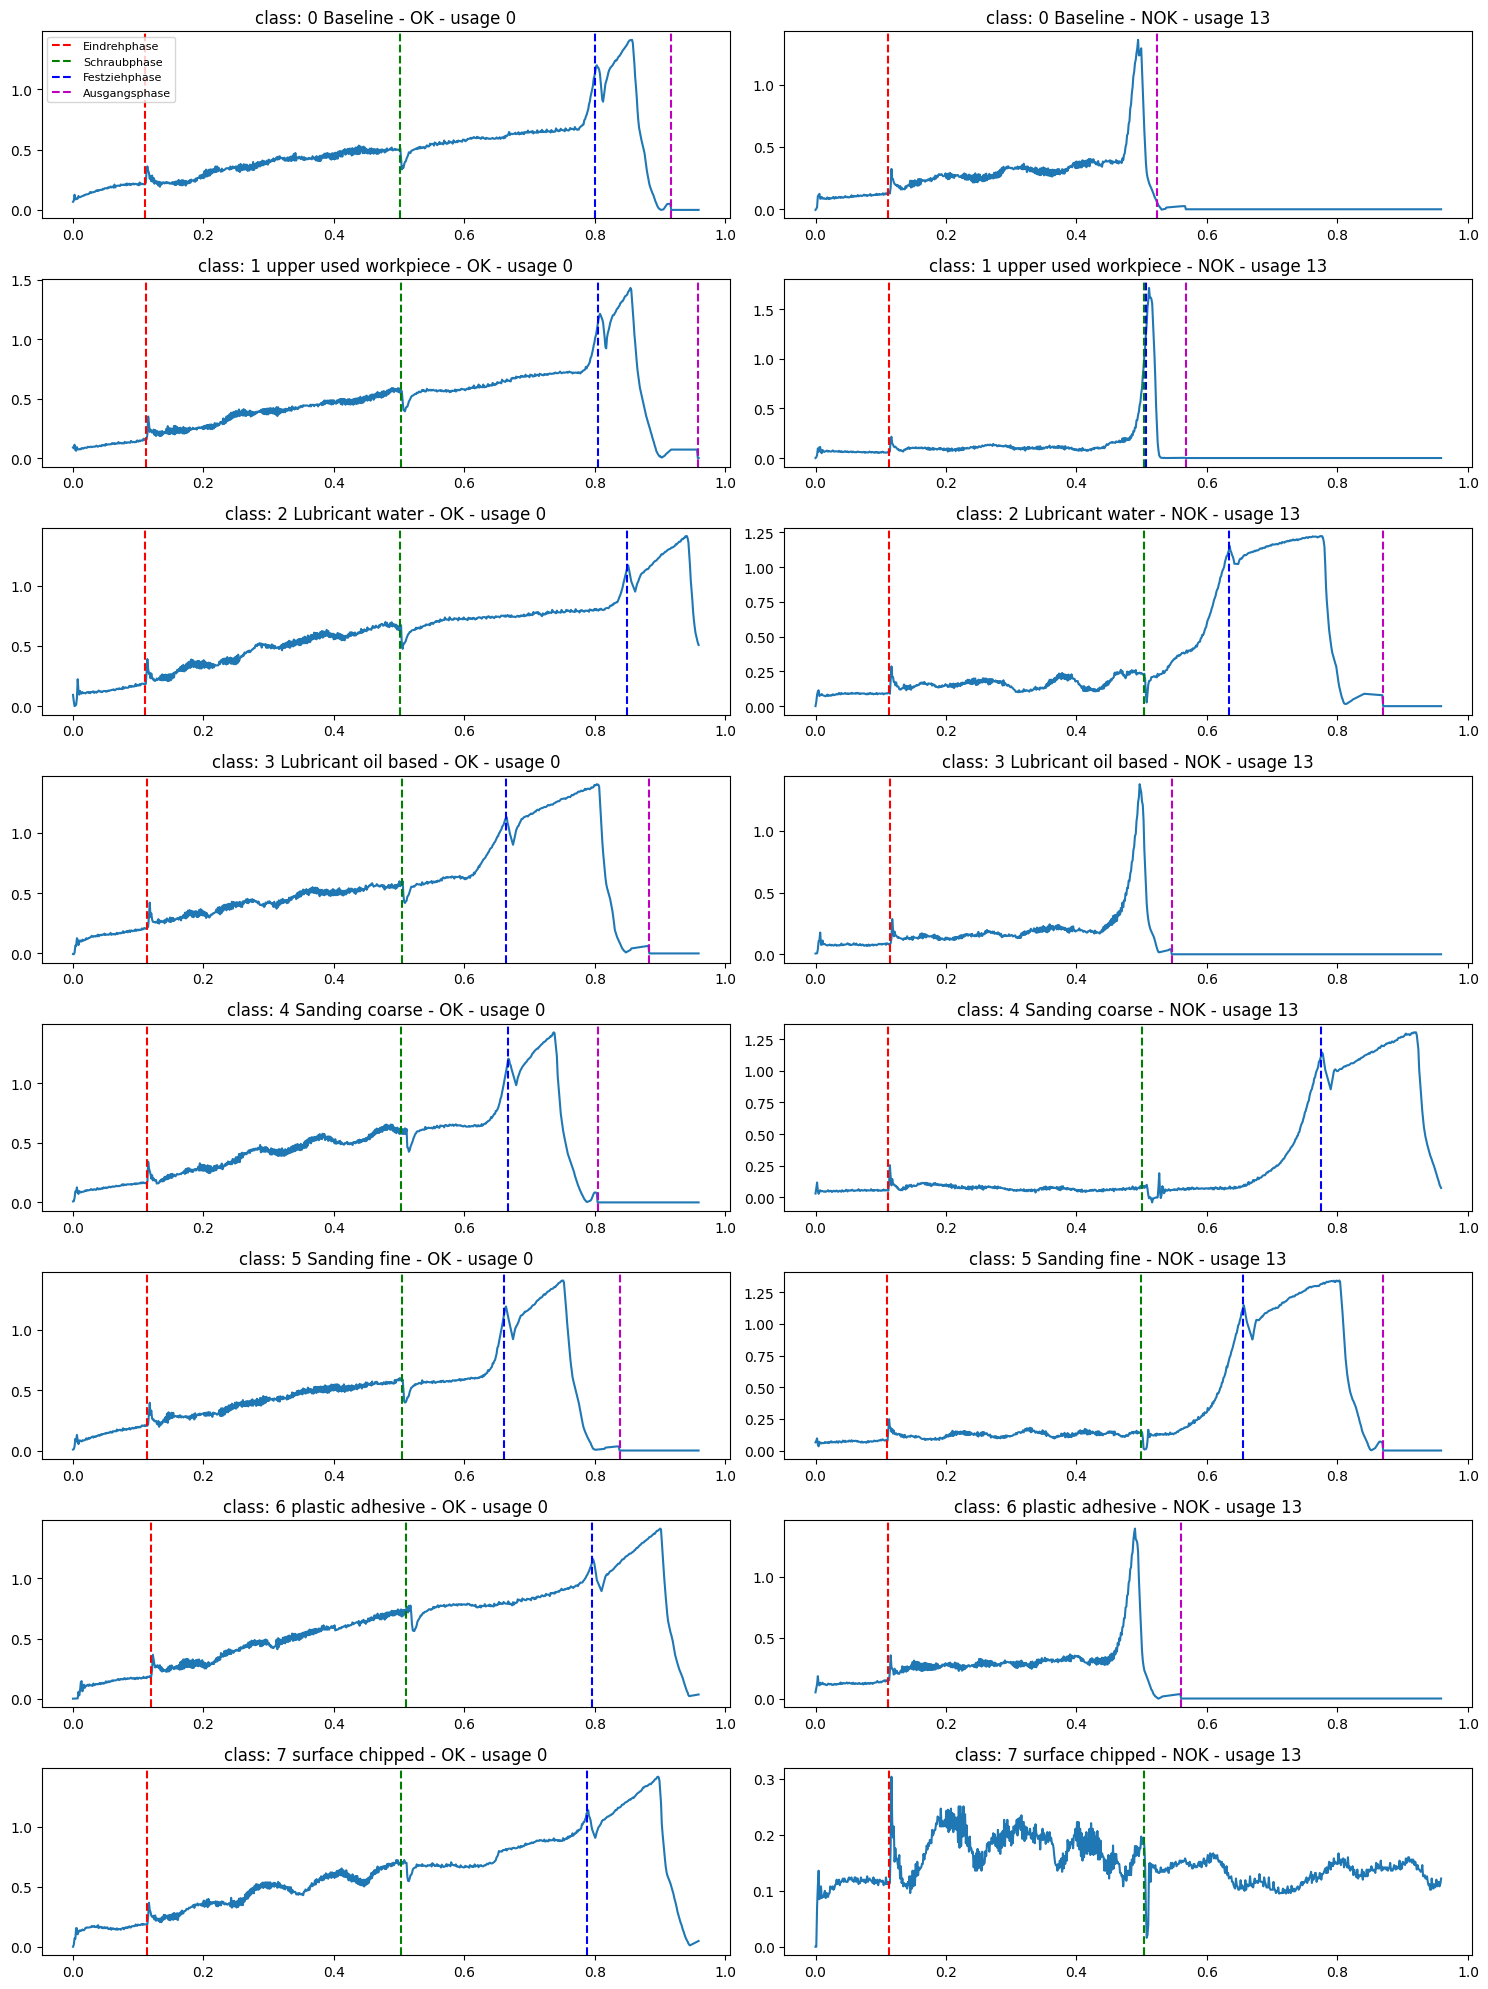

In [17]:
# plots aller klasvalues mit unterschiedlichem usage und workpiece result
fig, axs = plt.subplots(8,2, figsize=(15,20))
axs[0,0].plot(y_c0,x_c0)
axs[0,0].set_title("class: 0 Baseline - OK - usage 0")
axs[0,1].plot(y_c0_NOK,x_c0_NOK)
axs[0,1].set_title("class: 0 Baseline - NOK - usage 13")
axs[1,0].plot(y_c1,x_c1)
axs[1,0].set_title("class: 1 upper used workpiece - OK - usage 0")
axs[1,1].plot(y_c1_NOK,x_c1_NOK)
axs[1,1].set_title("class: 1 upper used workpiece - NOK - usage 13")
axs[2,0].plot(y_c2,x_c2)
axs[2,0].set_title("class: 2 Lubricant water - OK - usage 0")
axs[2,1].plot(y_c2_NOK,x_c2_NOK)
axs[2,1].set_title("class: 2 Lubricant water - NOK - usage 13")
axs[3,0].plot(y_c3,x_c3)
axs[3,0].set_title("class: 3 Lubricant oil based - OK - usage 0")
axs[3,1].plot(y_c3_NOK,x_c3_NOK)
axs[3,1].set_title("class: 3 Lubricant oil based - NOK - usage 13")
axs[4,0].plot(y_c4,x_c4)
axs[4,0].set_title("class: 4 Sanding coarse - OK - usage 0")
axs[4,1].plot(y_c4_NOK,x_c4_NOK)
axs[4,1].set_title("class: 4 Sanding coarse - NOK - usage 13")
axs[5,0].plot(y_c5,x_c5)
axs[5,0].set_title("class: 5 Sanding fine - OK - usage 0")
axs[5,1].plot(y_c5_NOK,x_c5_NOK)
axs[5,1].set_title("class: 5 Sanding fine - NOK - usage 13")
axs[6,0].plot(y_c6,x_c6)
axs[6,0].set_title("class: 6 plastic adhesive - OK - usage 0")
axs[6,1].plot(y_c6_NOK,x_c6_NOK)
axs[6,1].set_title("class: 6 plastic adhesive - NOK - usage 13")
axs[7,0].plot(y_c7,x_c7)
axs[7,0].set_title("class: 7 surface chipped - OK - usage 0")
axs[7,1].plot(y_c7_NOK,x_c7_NOK)
axs[7,1].set_title("class: 7 surface chipped - NOK - usage 13")

phases = [
    (1, "r", "Eindrehphase"),
    (2, "g", "Schraubphase"),
    (3, "b", "Festziehphase"),
    (-1, "m", "Ausgangsphase"),
]

# (ax, df_index, time_values)
targets = [
    (axs[0,0], 0, y_c0),        (axs[0,1], 89, y_c0_NOK),
    (axs[1,0], 2500, y_c1),     (axs[1,1], 3176, y_c1_NOK),
    (axs[2,0], 5000, y_c2),     (axs[2,1], 5653, y_c2_NOK),
    (axs[3,0], 7053, y_c3),     (axs[3,1], 6303, y_c3_NOK),
    (axs[4,0], 7500, y_c4),     (axs[4,1], 7526, y_c4_NOK),
    (axs[5,0], 8750, y_c5),     (axs[5,1], 8826, y_c5_NOK),
    (axs[6,0], 10000, y_c6),    (axs[6,1], 10055, y_c6_NOK),
    (axs[7,0], 11253, y_c7),    (axs[7,1], 11503, y_c7_NOK),
]

for ax, idx, t_vals in targets:
    step_arr = np.array(df.loc[idx, "step_values"])
    for step_val, color, label in phases:
        pos = np.where(step_arr == step_val)[0]
        if pos.size > 0:
            ax.axvline(x=t_vals[pos[0]], color=color, linestyle="--", label=label)

axs[0,0].legend(fontsize=8) 
plt.tight_layout()
plt.show()



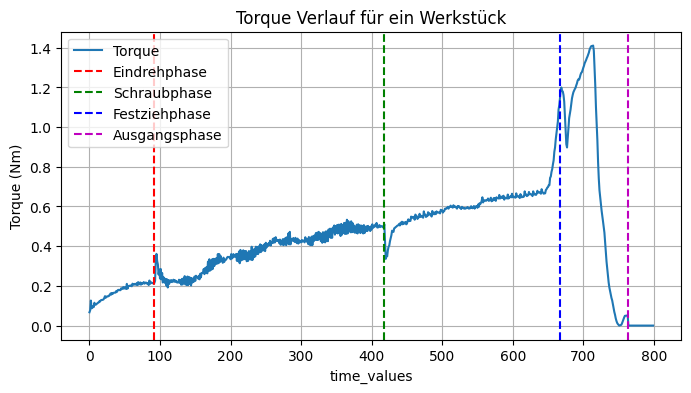

In [18]:
import matplotlib.pyplot as plt
torque_idx = df['torque_values'][0]
row = df.loc[0]
res_1 = (np.where(np.array(row['step_values']) == 1)[0][0])
res_2 = (np.where(np.array(row['step_values']) == 2)[0][0])
res_3 = (np.where(np.array(row['step_values']) == 3)[0][0])
if -1 in row['step_values']:
    res_min1= (np.where(np.array(row['step_values']) == -1)[0][0])

plt.figure(figsize=(8,4))
plt.plot(torque_idx, label='Torque')
plt.xlabel('time_values')
# Phase 0 sucht es das loch bzw. die position bis zum ansetzen
plt.axvline(x=res_1, color='r', linestyle='--', label='Eindrehphase') # hier wird die schraube eingedreht
plt.axvline(x=res_2, color='g', linestyle='--', label='Schraubphase') # pretightening also dreht rein bis "passgenauigkeit" erreicht
# Hookesche Gesetz besagt dass die kraft proportional zur dehnung ist, demnach steigt torque mit zunehmender dehnung -> sollte das nicht der fall sein, ggf. fehler, werkstückbruch oder so
plt.axvline(x=res_3, color='b', linestyle='--', label='Festziehphase') # großer kraftaufwand da stark angezogen (festes anziehen)
if -1 in row['step_values']:
    plt.axvline(x=res_min1, color='m', linestyle='--', label='Ausgangsphase') # lösen vom werkstück
plt.ylabel('Torque (Nm)')
plt.title('Torque Verlauf für ein Werkstück')
plt.grid(True)
plt.legend()
plt.show()

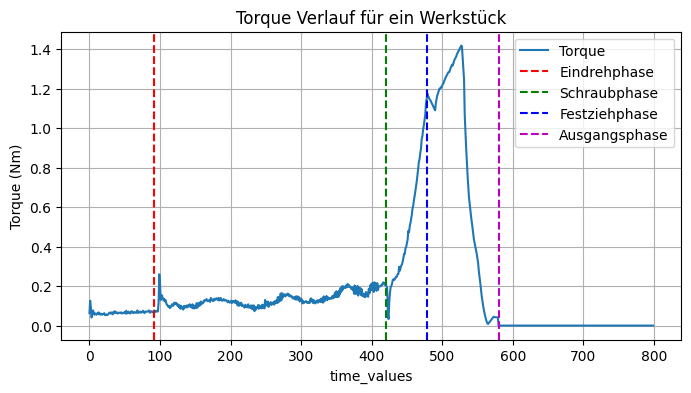

In [19]:
import matplotlib.pyplot as plt
torque_idx = df['torque_values'][6025]
row = df.loc[6025]
res_1 = (np.where(np.array(row['step_values']) == 1)[0][0])
res_2 = (np.where(np.array(row['step_values']) == 2)[0][0])
res_3 = (np.where(np.array(row['step_values']) == 3)[0][0])
if -1 in row['step_values']:
    res_min1= (np.where(np.array(row['step_values']) == -1)[0][0])

plt.figure(figsize=(8,4))
plt.plot(torque_idx, label='Torque')
plt.xlabel('time_values')
# Phase 0 sucht es das loch bzw. die position bis zum ansetzen
plt.axvline(x=res_1, color='r', linestyle='--', label='Eindrehphase') # hier wird die schraube eingedreht
plt.axvline(x=res_2, color='g', linestyle='--', label='Schraubphase') # pretightening also dreht rein bis "passgenauigkeit" erreicht
# Hookesche Gesetz besagt dass die kraft proportional zur dehnung ist, demnach steigt torque mit zunehmender dehnung -> sollte das nicht der fall sein, ggf. fehler, werkstückbruch oder so
plt.axvline(x=res_3, color='b', linestyle='--', label='Festziehphase') # großer kraftaufwand da stark angezogen (festes anziehen)
if -1 in row['step_values']:
    plt.axvline(x=res_min1, color='m', linestyle='--', label='Ausgangsphase') # lösen vom werkstück
plt.ylabel('Torque (Nm)')
plt.title('Torque Verlauf für ein Werkstück')
plt.grid(True)
plt.legend()
plt.show()


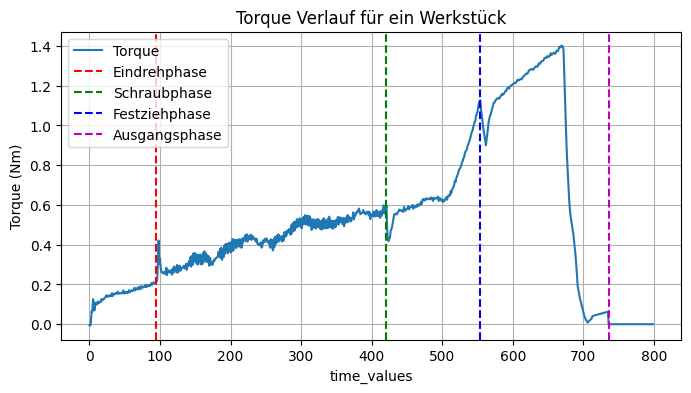

In [20]:
torque_idx = df['torque_values'][7053]
row = df.loc[7053]
res_1 = (np.where(np.array(row['step_values']) == 1)[0][0])
res_2 = (np.where(np.array(row['step_values']) == 2)[0][0])
res_3 = (np.where(np.array(row['step_values']) == 3)[0][0])
if -1 in row['step_values']:
    res_min1= (np.where(np.array(row['step_values']) == -1)[0][0])

plt.figure(figsize=(8,4))
plt.plot(torque_idx, label='Torque')
plt.xlabel('time_values')
# Phase 0 sucht es das loch bzw. die position bis zum ansetzen
plt.axvline(x=res_1, color='r', linestyle='--', label='Eindrehphase') # hier wird die schraube eingedreht
plt.axvline(x=res_2, color='g', linestyle='--', label='Schraubphase') # pretightening also dreht rein bis "passgenauigkeit" erreicht
# Hookesche Gesetz besagt dass die kraft proportional zur dehnung ist, demnach steigt torque mit zunehmender dehnung -> sollte das nicht der fall sein, ggf. fehler, werkstückbruch oder so
plt.axvline(x=res_3, color='b', linestyle='--', label='Festziehphase') # großer kraftaufwand da stark angezogen (festes anziehen)
if -1 in row['step_values']:
    plt.axvline(x=res_min1, color='m', linestyle='--', label='Ausgangsphase') # lösen vom werkstück
plt.ylabel('Torque (Nm)')
plt.title('Torque Verlauf für ein Werkstück')
plt.grid(True)
plt.legend()
plt.show()

In [21]:
print(df['workpiece_result'].unique())
print(np.unique(df['step_values'][6250]))
df.dtypes
print(type(df['step_values'][0]))
print(type(df['workpiece_result'][0]))

['OK' 'NOK']
[0 1 2 3]
<class 'list'>
<class 'str'>
